## GROUP WORK

## PART 1

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm 


In [10]:
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
chl

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [11]:
# Region boundaries
lon_min = -135
lon_max = -115
lat_min = 30
lat_max = 45

# Subset region
chl_region = chl.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

chl_region

<xarray.Dataset> Size: 4kB
Dimensions:  (time: 12, lat: 0, lon: 480)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [12]:

bathy = xr.open_dataset("GMRTv4_4_1_20260512topo.grd")
print(bathy)


<xarray.Dataset> Size: 2MB
Dimensions:    (side: 2, xysize: 256022)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 2MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...


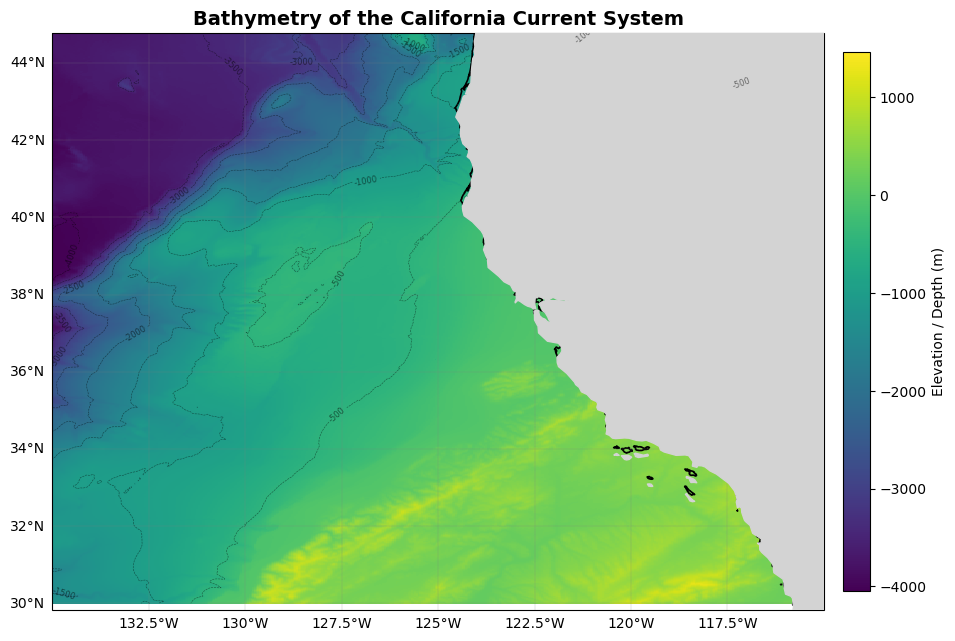

In [13]:
# --- reshape data ---
nx = int(bathy["dimension"].values[0])
ny = int(bathy["dimension"].values[1])

z = bathy["z"].values.reshape(ny, nx)

# --- build coordinate grid ---
x = np.linspace(lon_min, lon_max, nx)
y = np.linspace(lat_min, lat_max, ny)
X, Y = np.meshgrid(x, y)

# --- figure ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- main bathymetry field ---
im = ax.pcolormesh(
    X, Y, z,
    cmap="viridis",   # deeper = darker/more intense
    shading="auto",
    transform=ccrs.PlateCarree()
)

# --- contour lines (like your example image) ---
contours = ax.contour(
    X, Y, z,
    levels=np.arange(-5000, 0, 500),
    colors="black",
    linewidths=0.4,
    alpha=0.5,
    transform=ccrs.PlateCarree()
)

ax.clabel(contours, inline=True, fontsize=6, fmt="%d")

# --- coastline + land styling ---
ax.coastlines(resolution="10m", linewidth=1.2)
ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- gridlines (like professional maps) ---
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- extent ---
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# --- colorbar ---
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Elevation / Depth (m)")

# --- title ---
ax.set_title("Bathymetry of the California Current System", fontsize=14, fontweight="bold")

plt.show()

## PART 2

In [14]:
chl_mean = chl_region["chlor_a"].mean(dim="time")
chl_mean

<xarray.DataArray 'chlor_a' (lat: 0, lon: 480)> Size: 0B
array([], shape=(0, 480), dtype=float32)
Coordinates:
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [15]:
print(type(chl_mean))
print(chl_mean)

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray 'chlor_a' (lat: 0, lon: 480)> Size: 0B
array([], shape=(0, 480), dtype=float32)
Coordinates:
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [16]:
import xarray as xr

ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

In [3]:
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
  

In [6]:
chl = ds["chlor_a"]      # or whatever variable name appears
chl_mean = chl.mean(dim="time")

NameError: name 'lon_min' is not defined

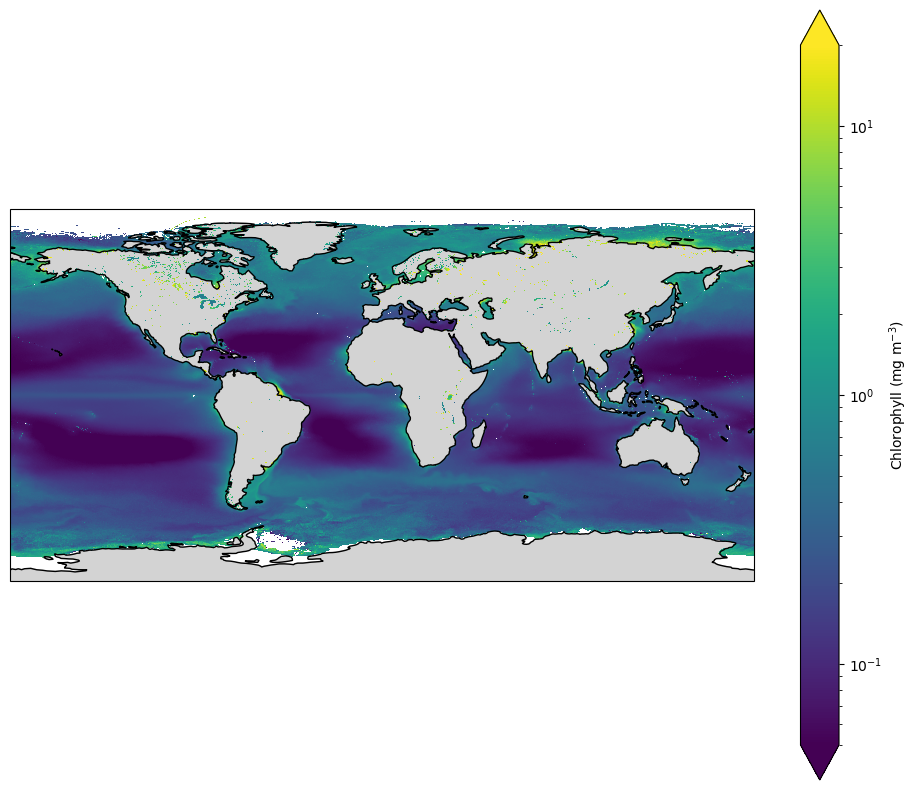

In [9]:
fig = plt.figure(figsize=(12,10))

ax = plt.axes(projection=ccrs.PlateCarree())

chl_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=20),
    cbar_kwargs={"label": "Chlorophyll (mg m$^{-3}$)"}
)

ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

ax.set_title("Mean Annual Chlorophyll Concentration")

plt.show()

In [4]:
print(ds.lat.values[0], ds.lat.values[-1])

# --------------------------------------------------
# Fix latitude slicing automatically
# --------------------------------------------------
if ds.lat.values[0] > ds.lat.values[-1]:
    lat_slice = slice(max(lat_min, lat_max),
                      min(lat_min, lat_max))
else:
    lat_slice = slice(min(lat_min, lat_max),
                      max(lat_min, lat_max))

# --------------------------------------------------
# Subset to YOUR bathymetry region
# --------------------------------------------------
subset = ds.sel(
    lon=slice(min(lon_min, lon_max),
              max(lon_min, lon_max)),
    lat=lat_slice
)

# --------------------------------------------------
# Extract chlorophyll variable
# --------------------------------------------------
chl = subset["chlor_a"]

# --------------------------------------------------
# Remove invalid values safely
# --------------------------------------------------
chl = chl.where(np.isfinite(chl))
chl = chl.where(chl > 0)

# --------------------------------------------------
# Check if subset contains data
# --------------------------------------------------
print("Valid values:",
      np.isfinite(chl).sum().values)

# --------------------------------------------------
# Monthly mean
# --------------------------------------------------
monthly_mean = chl.groupby(
    "time.month"
).mean(skipna=True)

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 12),
    subplot_kw={
        "projection":
        ccrs.PlateCarree()
    }
)

axes = axes.flatten()

month_names = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

# --------------------------------------------------
# Plot monthly maps
# --------------------------------------------------
for i in range(12):

    ax = axes[i]

    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        norm=LogNorm(vmin=0.05, vmax=20),
        add_colorbar=False
    )

    ax.coastlines(resolution="10m")

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray"
    )

    ax.set_extent([
        lon_min,
        lon_max,
        lat_min,
        lat_max
    ])

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False

    # --------------------------------------------------
    # FIX: Only show Y-axis labels on first column
    # (January, May, September)
    # --------------------------------------------------
    if i % 4 != 0:
        gl.left_labels = False

    ax.set_title(month_names[i])

# --------------------------------------------------
# Shared colorbar (BOTTOM)
# --------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    shrink=0.8,
    pad=0.08,
    aspect=40
)

cbar.set_label(
    "Chlorophyll-a (mg m$^{-3}$)"
)

fig.suptitle(
    "Monthly Mean Chlorophyll Concentration",
    fontsize=16
)

plt.subplots_adjust(
    hspace=0.25,
    wspace=0.10,
    bottom=0.12,
    top=0.93
)

plt.show()

89.97916666666667 -89.97916666666666


NameError: name 'lat_min' is not defined

89.97916666666667 -89.97916666666666
Valid values: 1421332


C:\Users\AphileV\AppData\Local\Temp\ipykernel_23628\2623607676.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


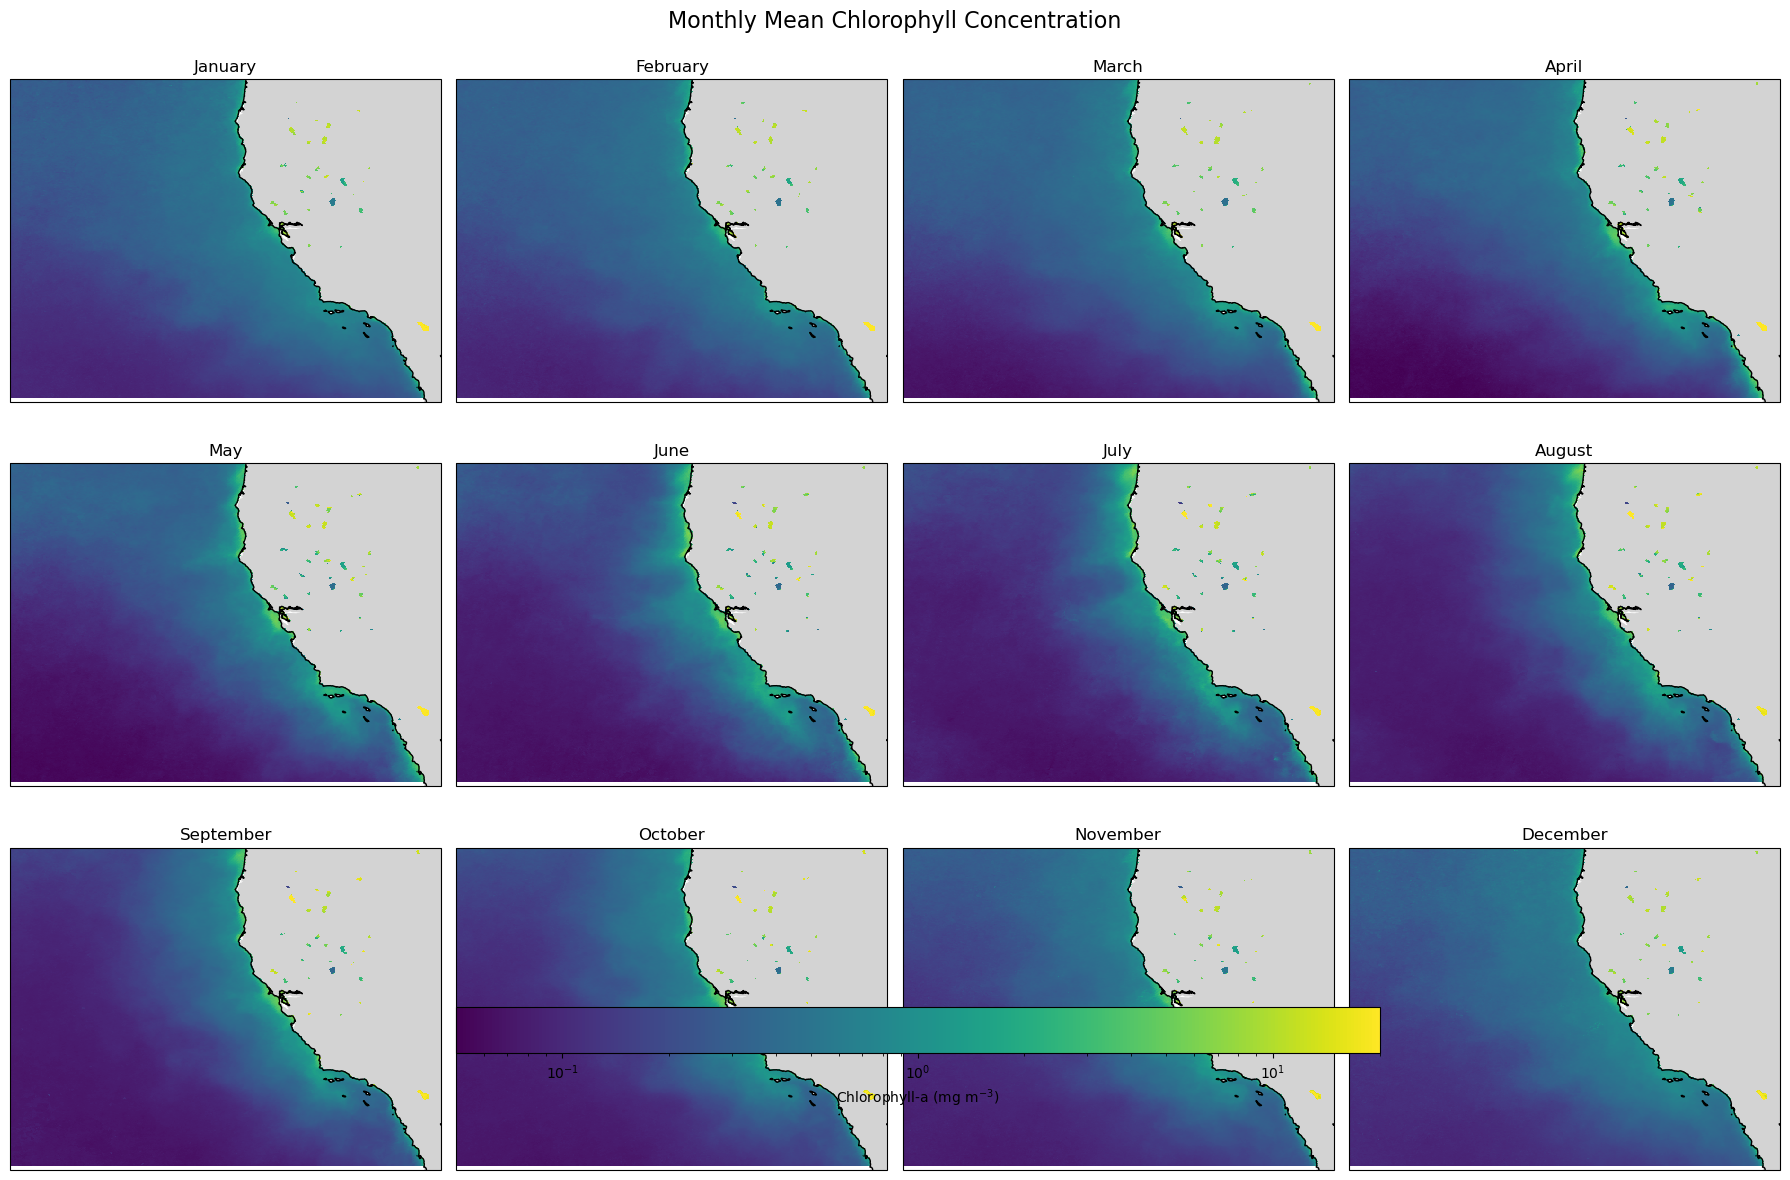

In [20]:
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc"
)

# --------------------------------------------------
# Check latitude order in dataset
# --------------------------------------------------
print(ds.lat.values[0], ds.lat.values[-1])

# --------------------------------------------------
# Fix latitude slicing automatically
# --------------------------------------------------
if ds.lat.values[0] > ds.lat.values[-1]:
    # Latitude decreases (north to south)
    lat_slice = slice(max(lat_min, lat_max),
                      min(lat_min, lat_max))
else:
    # Latitude increases (south to north)
    lat_slice = slice(min(lat_min, lat_max),
                      max(lat_min, lat_max))

# --------------------------------------------------
# Subset to YOUR bathymetry region
# --------------------------------------------------
subset = ds.sel(
    lon=slice(min(lon_min, lon_max),
              max(lon_min, lon_max)),
    lat=lat_slice
)

# --------------------------------------------------
# Extract chlorophyll variable
# --------------------------------------------------
chl = subset["chlor_a"]

# --------------------------------------------------
# Remove invalid values safely
# --------------------------------------------------
chl = chl.where(np.isfinite(chl))
chl = chl.where(chl > 0)

# --------------------------------------------------
# Check if subset contains data
# --------------------------------------------------
print("Valid values:",
      np.isfinite(chl).sum().values)

# --------------------------------------------------
# Monthly mean
# --------------------------------------------------
monthly_mean = chl.groupby(
    "time.month"
).mean(skipna=True)

# --------------------------------------------------
# Create figure
# --------------------------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(18, 12),
    subplot_kw={
        "projection":
        ccrs.PlateCarree()
    }
)

axes = axes.flatten()

# Month names
month_names = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

# --------------------------------------------------
# Plot monthly maps
# --------------------------------------------------
for i in range(12):

    ax = axes[i]

    data = monthly_mean.sel(
        month=i+1
    )

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        norm=LogNorm(vmin=0.05, vmax=20),
        add_colorbar=False
    )

    ax.coastlines(resolution="10m")

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray"
    )

    ax.set_extent([
        lon_min,
        lon_max,
        lat_min,
        lat_max
    ])

    ax.set_title(
        month_names[i]
    )

# --------------------------------------------------
# Shared colorbar
# --------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.05
)

cbar.set_label(
    "Chlorophyll-a (mg m$^{-3}$)"
)

fig.suptitle(
    "Monthly Mean Chlorophyll Concentration",
    fontsize=16
)

plt.tight_layout()
plt.show()

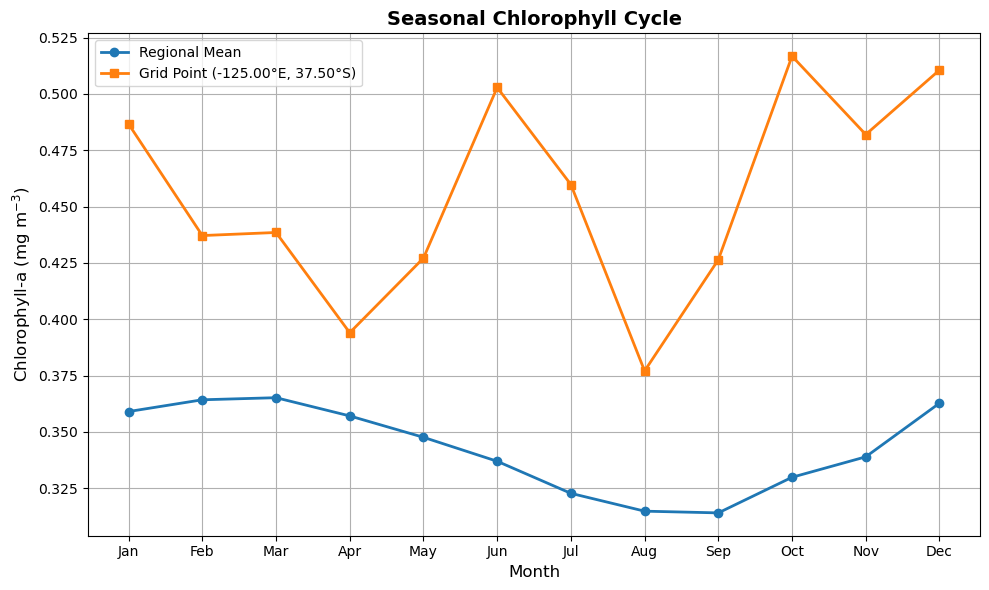

In [29]:
# Fix latitude slicing automatically
# --------------------------------------------------
if ds.lat.values[0] > ds.lat.values[-1]:
    lat_slice = slice(
        max(lat_min, lat_max),
        min(lat_min, lat_max)
    )
else:
    lat_slice = slice(
        min(lat_min, lat_max),
        max(lat_min, lat_max)
    )

# --------------------------------------------------
# Subset to YOUR bathymetry region
# --------------------------------------------------
subset = ds.sel(
    lon=slice(
        min(lon_min, lon_max),
        max(lon_min, lon_max)
    ),
    lat=lat_slice
)

# --------------------------------------------------
# Extract chlorophyll variable
# --------------------------------------------------
chl = subset["chlor_a"]

# --------------------------------------------------
# Remove invalid values
# --------------------------------------------------
chl = chl.where(chl > 0)

# --------------------------------------------------
# 1. Regional mean seasonal cycle
# --------------------------------------------------
regional_mean = chl.mean(
    dim=["lat", "lon"],
    skipna=True
)

# --------------------------------------------------
# 2. Select a comparison grid point
# (center of your study area)
# --------------------------------------------------
point_lat = (lat_min + lat_max) / 2
point_lon = (lon_min + lon_max) / 2

point_series = chl.sel(
    lat=point_lat,
    lon=point_lon,
    method="nearest"
)

# --------------------------------------------------
# Month labels
# --------------------------------------------------
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

months = np.arange(1, 13)

# --------------------------------------------------
# Create plot
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Regional mean
plt.plot(
    months,
    regional_mean,
    marker="o",
    linewidth=2,
    label="Regional Mean"
)

# Single grid point
plt.plot(
    months,
    point_series,
    marker="s",
    linewidth=2,
    label=f"Grid Point ({point_lon:.2f}°E, {point_lat:.2f}°S)"
)

# --------------------------------------------------
# Customize plot
# --------------------------------------------------
plt.xticks(months, month_names)

plt.xlabel("Month", fontsize=12)
plt.ylabel(
    "Chlorophyll-a (mg m$^{-3}$)",
    fontsize=12
)

plt.title(
    "Seasonal Chlorophyll Cycle",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()